# Notebook 3: constrained density recovery

This walkthrough is synthetic. Open it from the extracted project folder. The executable cell regenerates the figures and results; rerun this builder to refresh the embedded figure attachments after changing the experiment. Paper references and numerical assumptions appear alongside the derivation.


# Recovering a density from noisy option prices
## Milestone 3: a constrained synthetic benchmark
Joel Cerraga | Quant research project | Development version 0.3

**Status:** the constrained estimator has been implemented and tested using synthetic prices. It has not been calibrated to the candidate SPX snapshot. The market-data observation-time and quote-size questions remain unresolved.

### 1. Purpose of the subsequent experiment

The first experiment recovered a density from theoretical call prices. It also demonstrated that directly differentiating perturbed prices could produce negative estimates. The subsequent task therefore involved constructing a method that admits only valid probability distributions, while allowing imperfect agreement with noisy input prices.

As Aït-Sahalia and Duarte (2003) explain in *Nonparametric option pricing under shape restrictions* [9, §2], option-price estimation should respect the direction and curvature restrictions implied by no arbitrage. This motivates our use of a constrained estimator. We do not implement their locally polynomial estimator: the method developed here uses probabilities assigned to fixed terminal-level intervals.

### 2. Representing the distribution

Let interval $j$ have lower boundary $a_j$, upper boundary $b_j$, width $\Delta s_j=b_j-a_j$ and centre $m_j=(a_j+b_j)/2$. Its probability mass is $w_j$. We assume that the density is constant within each interval:

$$\widehat f_Q(s)=\sum_{j=1}^{J}\frac{w_j}{\Delta s_j}\,\mathbf{1}_{[a_j,b_j)}(s).\tag{9}$$

Equation (9) is the project's histogram representation. The interval indicator is one inside the specified interval and zero elsewhere. The stepwise appearance of the density is therefore intentional; it is not a rendering error. Outside the chosen support the fitted density is zero.

The weights satisfy:

$$w_j\geq0,\qquad \sum_{j=1}^{J}w_j=1,\qquad\sum_{j=1}^{J}m_jw_j=F(T).\tag{10}$$

Bahra (1997), in the Mathematical appendix of his Bank of England paper [1], relates the distribution's mean to the forward price. Equation (10) applies that relationship to the interval representation, alongside non-negativity and unit total mass. These are imposed conditions, not independent discoveries about the recovered distribution. In this benchmark the forward is known from the synthetic model; a market application must establish it separately.

### 3. Calculating prices from interval probabilities

As Bahra sets out in his treatment of risk-neutral valuation [1], option prices follow from the discounted expected payoff. Integrating the call payoff over each uniform interval gives the following project-specific discretisation of Equation (1):

$$\widehat C(K_i)=\sum_{j=1}^{J}A_{ij}w_j,\qquad A_{ij}=\frac{D(T)}{2\Delta s_j}\left[(b_j-K_i)_+^2-(a_j-K_i)_+^2\right].\tag{11}$$

Here, $(x)_+=\max(x,0)$ and $D(T)=e^{-rT}$. The matrix entry $A_{ij}$ is the discounted expected call payoff if all probability were uniformly distributed within interval $j$. It is not a bid or ask quote.

Equation (11) is linear in the unknown probabilities. Because every component is the expected payoff under a nonnegative distribution, the resulting call curve is decreasing and convex in strike. Its slope lies between $-D(T)$ and zero, its value at zero strike is $D(T)F(T)$, and it becomes zero at strikes beyond the upper support boundary. These properties follow from Equations (10)–(11). The call price is continuously differentiable and piecewise quadratic; its second derivative gives Equation (9) within interval interiors. At the interval boundaries, the density may jump.

### 4. Balancing price agreement and smoothness

Boyd and Vandenberghe (2004), in *Convex Optimization*, describe regularisation as a way to balance a data-fit objective against a penalty on the solution [11, §6.3]. Their discussion of smoothing penalties motivates a second-difference penalty on adjacent density heights. For equally spaced intervals, define $g_j=w_j/(\Delta s_j/F)$, the dimensionless density height in forward-normalised coordinates. The fitted probabilities minimise:

$$\min_{\mathbf w}\;\frac{1}{N}\sum_{i=1}^{N}\left(\frac{\sum_j A_{ij}w_j-y_i}{F}\right)^2+\frac{\lambda}{J-2}\sum_{j=1}^{J-2}(g_{j+2}-2g_{j+1}+g_j)^2,\quad\text{subject to Equation (10)}.\tag{12}$$

In Equation (12), $y_i$ is a noisy synthetic call price and $\lambda$ controls the smoothing penalty. This exact discretisation and its scaling are project choices, not a formula quoted from Boyd and Vandenberghe. The second differences are not divided by squared interval spacing, so the same numerical penalty is not directly comparable across different numbers of intervals.

As Boyd and Vandenberghe describe in §4.4 [11], a convex quadratic objective with affine constraints is a convex quadratic programme. Our objective has that form. The implementation uses sequential least-squares programming (SLSQP), supplies an analytical gradient and checks the solver's success flag and constraint residuals. No negative masses are clipped and no density is renormalised after fitting. Numerical solver success is not presented as a formal optimality certificate.

All observations have equal weight in this controlled experiment. No market bid–ask intervals are used. A production extension must consider quote-dependent uncertainty and test support, interval resolution and penalty selection.

### 5. Experiment settings and validation

The synthetic parameters remain those of Milestone 1: an initial level of 6,000, annual volatility of 20%, risk-free rate of 4%, continuous dividend yield of 1.5% and maturity of half a year. We generate 81 call prices over strikes from $0.65F$ to $1.45F$, then add independent Gaussian errors with standard deviation 0.5 index points and seed 2026. This is a new stress test, not a rerun of Figure 4's 0.05-point noise experiment.

The density has 120 intervals over $[0.3F,2.2F]$. Price fitting uses only the noisy prices, the supplied forward and discount factor, and the constraints. The analytical density is used only for evaluation. The central penalty $10^{-6}$ is an illustrative baseline; alternatives $10^{-8}$ and $10^{-4}$ assess sensitivity. It is not claimed to be an optimal penalty.

We assess price accuracy at 80 interleaved strikes omitted from fitting, against their known theoretical prices. This is a synthetic interpolation check, not a historical out-of-sample trading test. We also integrate the absolute density error numerically on the stated support. The exact benchmark probability outside that support is about $8.21\times10^{-9}$; the fitted model nevertheless imposes zero tail probability there. This favourable tail coverage is known only because the experiment is synthetic.



In [1]:
from run_constrained import main
result = main()


{
  "status": "synthetic_only",
  "noise_standard_deviation": 0.5,
  "seed": 2026,
  "quote_count": 81,
  "bins": 120,
  "forward": 6075.470709243807,
  "discount_factor": 0.9801986733067553,
  "support": [
    1822.641212773142,
    13366.035560336375
  ],
  "known_density_mass_outside_support": 8.213763654369586e-09,
  "raw_negative_density_points": 18,
  "baseline_penalty": 1e-06,
  "penalty_selection": "Predeclared illustrative middle setting; not selected by minimising benchmark error",
  "results": [
    {
      "penalty": 1e-08,
      "iterations": 50,
      "mass": 1.0000000000000016,
      "mean": 6075.470709243816,
      "minimum_bin_mass": 0.0,
      "noisy_quote_rmse": 0.3928968686792473,
      "withheld_clean_price_rmse": 0.28737241831255755,
      "integrated_density_absolute_error": 0.10856271918361246,
      "monotonicity_violations": 0,
      "convexity_violations": 0
    },
    {
      "penalty": 1e-06,
      "iterations": 106,
      "mass": 1.0000000000000009,
      

Table 5. Baseline constrained-fit diagnostics, using $\lambda=10^{-6}$.

| Check | Result | Interpretation |
|---|---:|---|
| Total fitted probability mass | 1.0000000000 | Imposed by Equation (10) |
| Fitted mean | 6,075.470709 | Imposed forward consistency |
| Negative fitted interval masses | 0 | Enforced non-negativity |
| Negative raw finite-difference estimates | 18 of 79 | Failure of direct differentiation on these noisy prices |
| Fitted-price RMSE against noisy inputs | 0.437732 index points | Training-data discrepancy |
| Price RMSE at withheld clean strikes | 0.246113 index points | Synthetic interpolation accuracy |
| Integrated absolute density error on support | 0.030998 | Density discrepancy; not a pointwise percentage error |
| Sampled decreasing-price or convexity violations | 0 | Numerical check of theoretical shape properties |

RMSE means root-mean-square error. The reported values are generated by `run_constrained.py`, not drawn from the cited papers. `tests/test_constrained.py` additionally checks pricing against independent numerical integration, exact reconstruction of a small known histogram, the price–density derivative relationship, invalid inputs and preservation of the Figure 4 notebook layout.

### 6. Results and interpretation



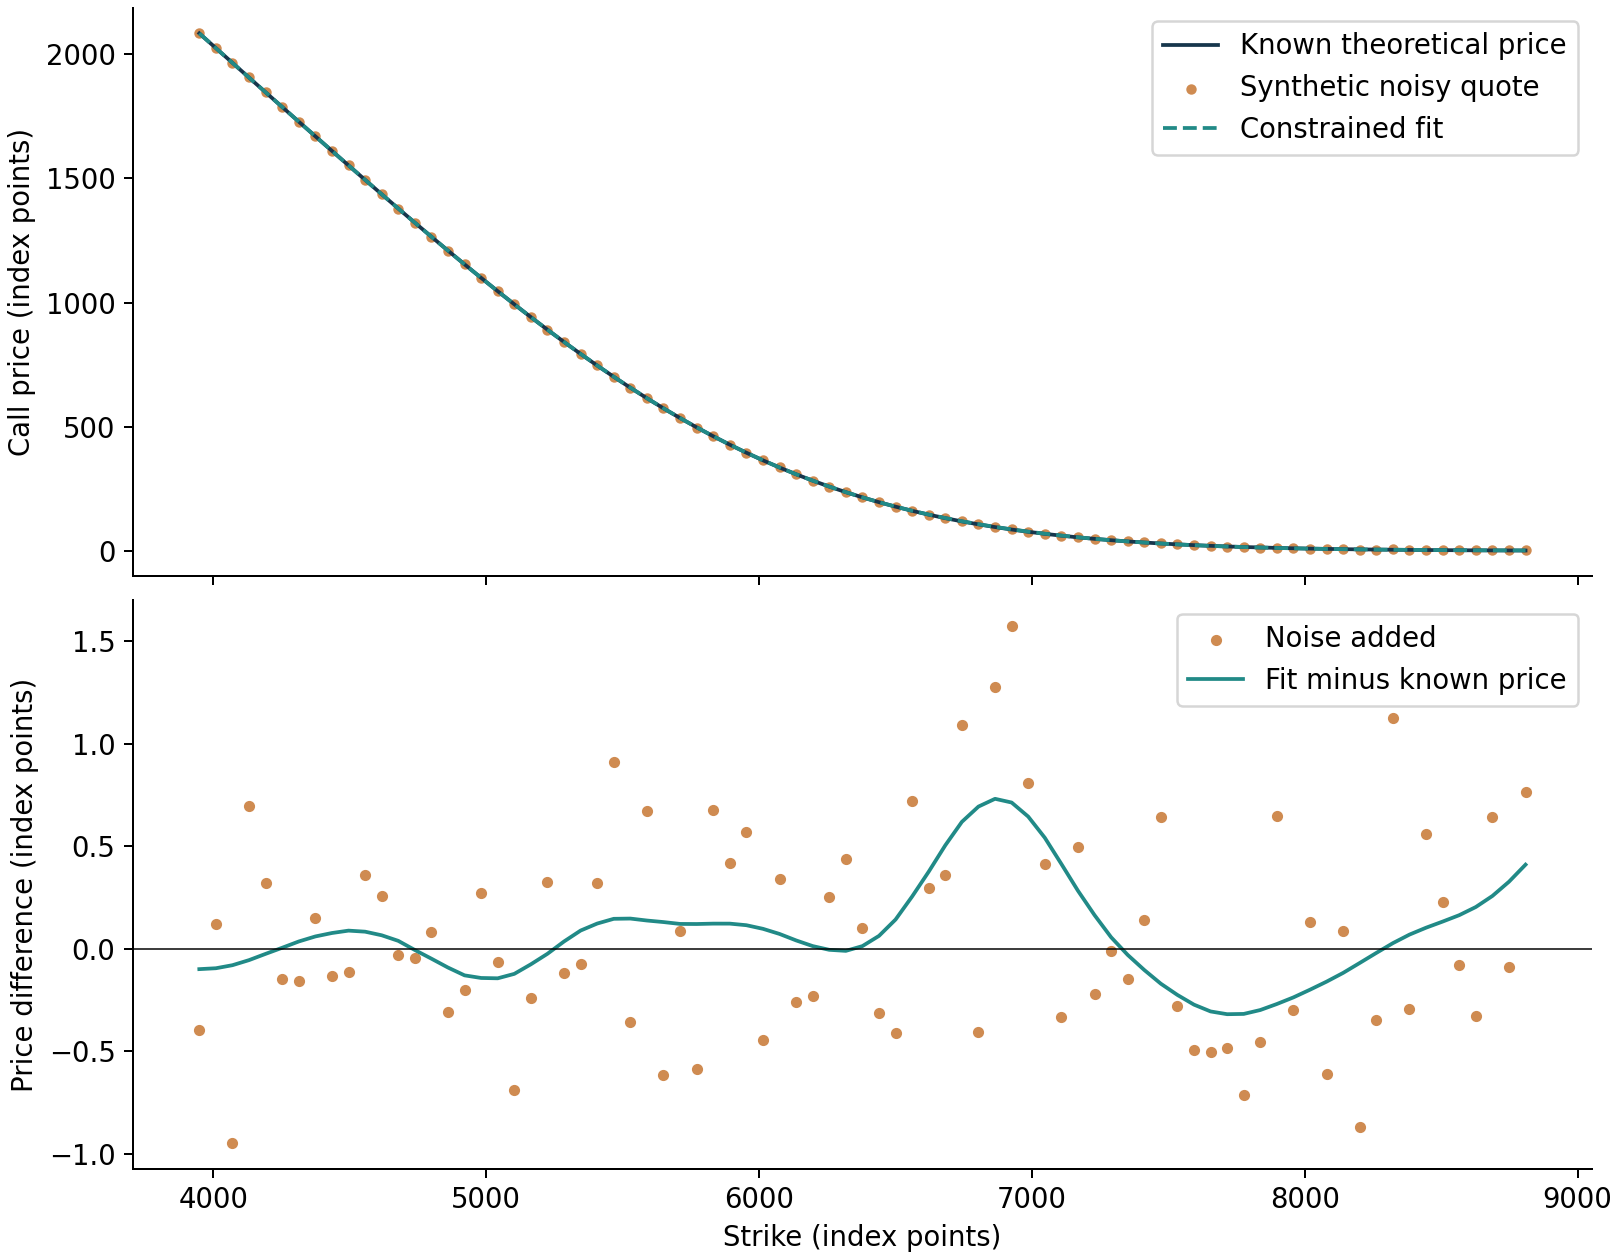




Figure 7. Synthetic call prices and the constrained fit for the baseline penalty. The upper panel shows prices; the lower panel compares the added price errors with the fitted price's deviation from the known value. Prices are in index points, not currency per contract.

As shown in Figure 7, the price curves appear almost coincident at the full scale. The residual panel is therefore necessary to expose the differences. The fitted curve does not interpolate every perturbed observation because Equation (12) balances price agreement with a penalty on changes in density height.



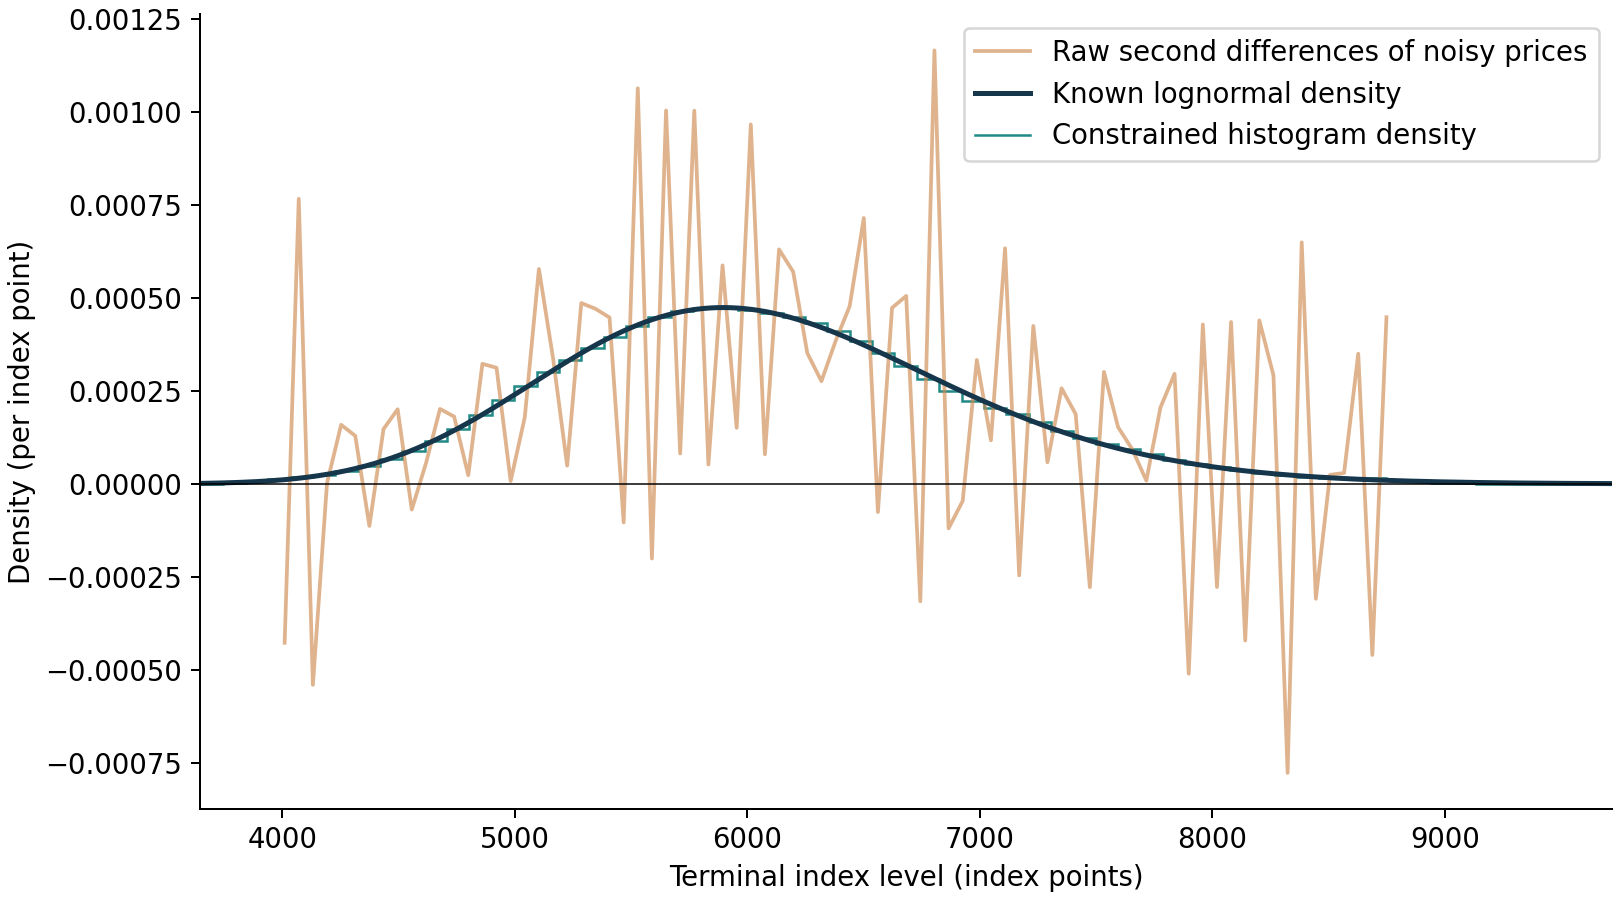




Figure 8. Known lognormal density, raw second differences of noisy call prices and the fitted histogram density. The display is cropped to $[0.6F,1.6F]$ for readability; fitting uses the wider support stated above. All inputs are synthetic.

As shown in Figure 8, raw differentiation produces oscillations and negative values. The constrained estimate tracks the broad shape of the known distribution without negative interval probabilities. This verifies the behaviour in the stated experiment, not the reliability of estimated market tails.



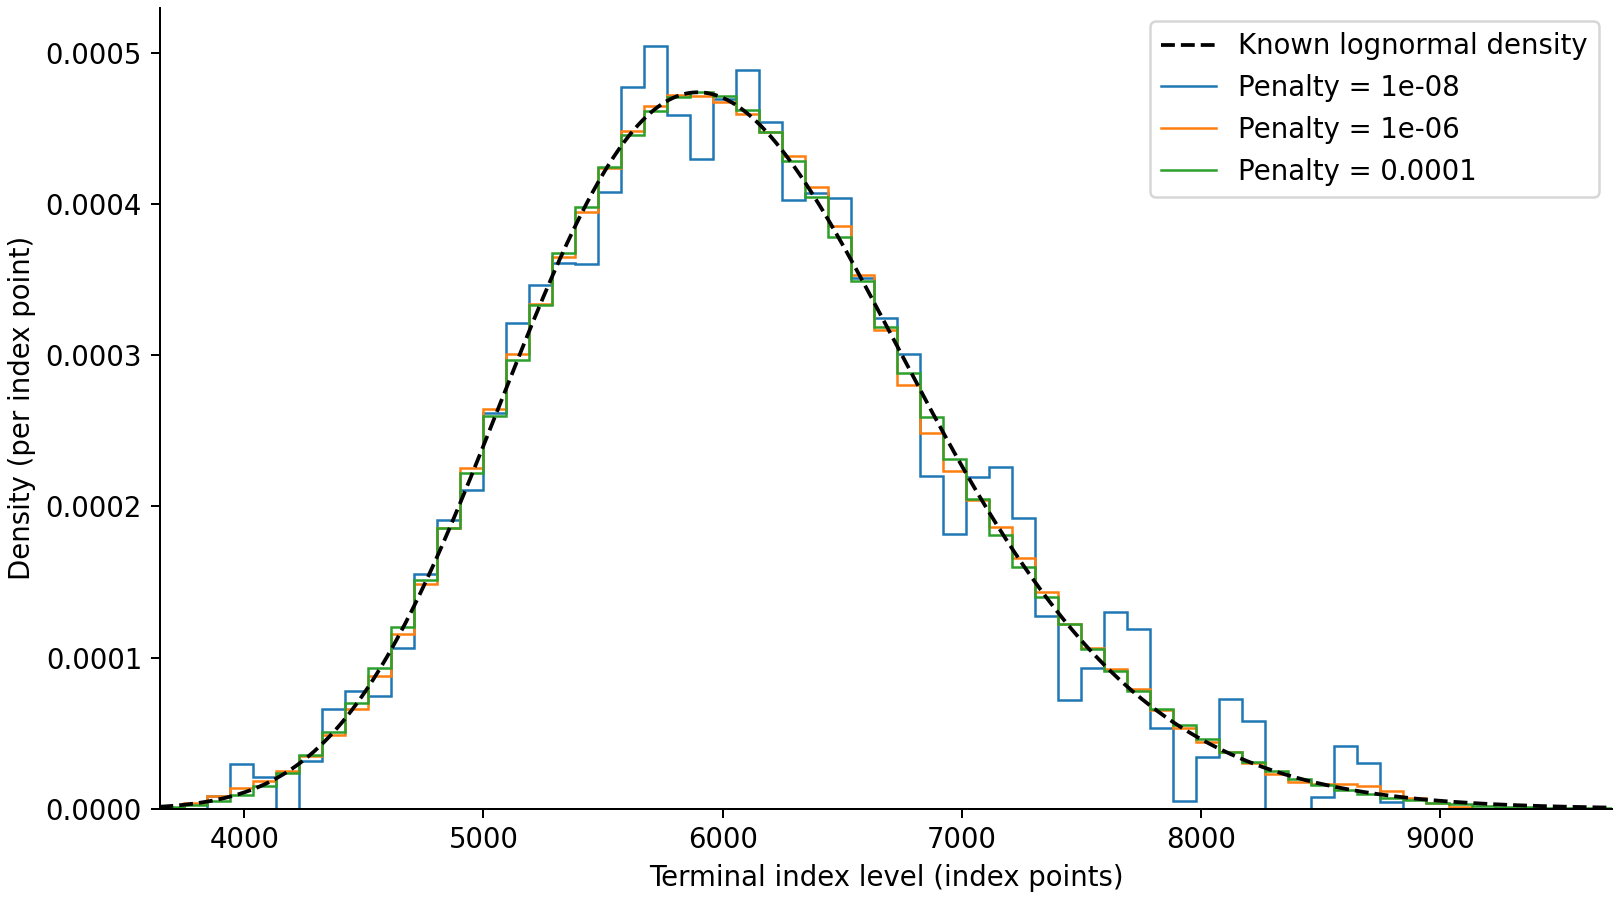




Figure 9. Histogram densities obtained with penalties $10^{-8}$, $10^{-6}$ and $10^{-4}$, with the same prices, interval grid and forward. The dashed curve is the known density. This comparison isolates the penalty setting within one noise realisation.

Table 6. Smoothing sensitivity in the synthetic experiment.

| Penalty | Noisy-input price RMSE | Withheld clean-price RMSE | Integrated absolute density error |
|---|---:|---:|---:|
| $10^{-8}$ | 0.392897 | 0.287372 | 0.108563 |
| $10^{-6}$ | 0.437732 | 0.246113 | 0.030998 |
| $10^{-4}$ | 0.458675 | 0.211071 | 0.025788 |

The price errors in Table 6 are measured in index points. For this example, stronger smoothing worsens agreement with noisy inputs while improving agreement with the known prices and density. This is an observed result for one model and random seed; stronger smoothing is not guaranteed to improve other datasets. Boyd and Vandenberghe's discussion of regularisation [11, §6.3] provides the methodological rationale for examining this trade-off.

### 7. Data-access status and limits of the current result

The earlier direct-feed check returned a timestamp string containing both date and time (`2026-09-19 17:58:02`), unlike the page payload's time-only value. The option-record array was identical to the stored candidate, and all bid and ask sizes remained zero. Neither a timezone nor the precise meaning of that timestamp was verified. This observation is recorded in `research/data_access_status.md`; it is not evidence of a newly synchronised market snapshot.

The estimator is ready for further synthetic validation. It is not yet a validated empirical SPX result. In addition to the data questions, future checks must examine different distribution shapes, random seeds, interval counts, support boundaries, forwards and smoothing choices. The current result contains no historical forecasting or trading claim.

### References

[1] B. Bahra (1997), “Implied risk-neutral probability density functions from option prices: theory and application,” Bank of England, Working Paper No. 66. [Paper](https://www.bankofengland.co.uk/-/media/boe/files/working-paper/1997/implied-risk-neutral-probability-density-functions-from-option-prices.pdf).

[9] Y. Aït-Sahalia and J. Duarte (2003), “Nonparametric option pricing under shape restrictions,” *Journal of Econometrics*, vol. 116, nos. 1–2, pp. 9–47. [Author-hosted paper](https://www.princeton.edu/~yacine/cnvx.pdf).

[11] S. Boyd and L. Vandenberghe (2004), *Convex Optimization*. Cambridge University Press, §§4.4 and 6.3, especially pp. 152–153 and 305–308. [Author-hosted book](https://web.stanford.edu/~boyd/cvxbook/bv_cvxbook.pdf).
